# Configration 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
from sklearn import model_selection, metrics
from sklearn.metrics import roc_curve, roc_auc_score
from scipy import stats


from mics import qrisk3, simulation

## Experiment 1 - Baseline MICS

Question: Does MICS occur when a risk model is retrained on outcomes produced from its initial deployment?

M1 was trained on an untreated population (A). It was then deployed on a second population (B) to allocate statins under NICE CG181, which lowers the true risk of treated patients (RRR = 0.25). M2 was then trained on those post-intervention outcomes. Both models are evaluated on an untreated third population (C), so any difference between them should come from the intervention rather than from the patients the model is applied on.

The experiment is run across 20 seeds at n = 100,000. The intervals are the empirical 2.5th–97.5th
percentiles across the simulation replicates.

### Multi-seed run

In [2]:
# Time a single full-sized  run before introdcuing the 20 seed-loop 
import time

start = time.time()
_ = simulation.run_simulation(0, n=100_000)
print(f"{time.time() - start:.1f} seconds")

12.5 seconds


In [3]:
# Create a folder to store the results of the simulation - 20 seeds, each with 100,000 samples
from pathlib import Path

results_dir = Path("Results/Experiment_1")
results_dir.mkdir(parents=True, exist_ok=True)

# Run the simulation for 20 different seeds and save the results to parquet files
# Start with one seed to test the simulation and ensure it runs correctly and then wrap the dictionary results in a on-row DataFrame and save it to a parquet file for each seed. 
# This will allow for easy aggregation and analysis of the results later on.
for seed in range(20):
    output_path = results_dir / f"seed_{seed}.parquet"

    # Add a guard which skips seeds already on the disk so the loop can resume without interruption,
    # and not re-compute what is already present
    if output_path.exists():
        continue
    
    result = simulation.run_simulation(seed, n=100_000)
    pl.DataFrame([result]).write_parquet(results_dir / f"seed_{seed}.parquet")
    print(f"seed {seed} done")

# Read all 20 files and combine them into a single DataFrame for analysis
multiseed_results = pl.read_parquet("Results/Experiment_1/*.parquet")
multiseed_results.shape

(20, 96)

In [4]:
headline_numbers = [
    "underprediction_vs_truth_pp",
    "m1_m2_pp_gap",
    "proportion_treated",
    "m1_auc", "m2_auc",
    "m1_n_flagged", "m2_n_flagged",
    "m1_mean_pred_high_risk", "m2_mean_pred_high_risk",
]

for col in headline_numbers:
    values = multiseed_results [col]
    print(f"{col}: {values.mean():.4f}  [{values.quantile(0.025):.4f}, {values.quantile(0.975):.4f}]")

# Find the under-prediction among patients whose true risk is above the 10% treatment threshold. 
# The population average is diluted by low-risk patients, where M2 predicting lower is a harmless error.
# This subgroup is where an under-prediction can push a patient below the threshold and cost them statin allocation.
# Computed rather than stored per run, so the interval comes from the same 20 seeds.
high_risk_gap = (
    multiseed_results["m1_mean_pred_high_risk"]
    - multiseed_results["m2_mean_pred_high_risk"]
) * 100

print(f"high_risk_gap_pp: {high_risk_gap.mean():.4f}  "
      f"[{high_risk_gap.quantile(0.025):.4f}, {high_risk_gap.quantile(0.975):.4f}]")

underprediction_vs_truth_pp: 2.5272  [2.3265, 2.7147]
m1_m2_pp_gap: 2.5295  [2.3615, 2.7452]
proportion_treated: 0.3917  [0.3873, 0.3997]
m1_auc: 0.8267  [0.8241, 0.8293]
m2_auc: 0.8266  [0.8240, 0.8293]
m1_n_flagged: 39122.6000  [38586.0000, 39539.0000]
m2_n_flagged: 34360.1500  [33836.0000, 34974.0000]
m1_mean_pred_high_risk: 0.2494  [0.2459, 0.2522]
m2_mean_pred_high_risk: 0.1905  [0.1874, 0.1935]
high_risk_gap_pp: 5.8904  [5.5247, 6.2517]


 ### Discrimination and threshold metrics 

In [5]:
# Table 1: Gpenerate the erformance and threshold metrics on Population C, summarised
# across 20 seeds as mean with the empirical 2.5th-97.5th (smallets and highest) percentile intervals 

# Empirical 95% intervals across 20 simulation replicates
metrics_names = ["auc", "pr_auc", "sensitivity", "specificity",
                "ppv", "npv", "f1", "n_flagged"]

rows = []
for metric in metrics_names:
    m1 = multiseed_results[f"m1_{metric}"].to_numpy()
    m2 = multiseed_results[f"m2_{metric}"].to_numpy()

    # Difference calculated per seen and then take the percentiles to get the interval on the dfference 
    # The interval should describe the chnage seen rather than the gap between the two seperately estimated means
    difference = m2 - m1 

    rows.append({
        "metric": metric,
        "m1_mean": np.mean(m1),
        "m1_p2.5": np.percentile(m1, 2.5),
        "m1_p97.5": np.percentile(m1, 97.5),
        "m2_mean": np.mean(m2),
        "m2_p2.5": np.percentile(m2, 2.5),
        "m2_p97.5": np.percentile(m2, 97.5),
        "difference_mean": np.mean(difference),
        "difference_p2.5": np.percentile(difference, 2.5),
        "difference_p97.5": np.percentile(difference, 97.5),
    })

summary = pl.DataFrame(rows)
summary 

metric,m1_mean,m1_p2.5,m1_p97.5,m2_mean,m2_p2.5,m2_p97.5,difference_mean,difference_p2.5,difference_p97.5
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""auc""",0.826713,0.824499,0.829094,0.826554,0.824413,0.829032,-0.000159,-0.000716,0.000348
"""pr_auc""",0.374371,0.36623,0.382622,0.373439,0.365845,0.381088,-0.000931,-0.003357,0.000773
"""sensitivity""",0.835458,0.830513,0.840375,0.788273,0.780072,0.796819,-0.047185,-0.054944,-0.039732
"""specificity""",0.670006,0.665482,0.674404,0.717691,0.712976,0.721962,0.047686,0.04214,0.053847
"""ppv""",0.258698,0.254382,0.262097,0.277918,0.273949,0.281518,0.01922,0.017059,0.021902
"""npv""",0.967258,0.966222,0.968086,0.960929,0.959717,0.962326,-0.00633,-0.007378,-0.005271
"""f1""",0.395059,0.389998,0.399532,0.410943,0.406021,0.415135,0.015884,0.014172,0.018357
"""n_flagged""",39122.6,38682.9,39508.6,34360.15,33858.325,34856.2,-4762.45,-5397.95,-4196.675


### Coefficeint attenuation with CIs

In [6]:
# Reshape the coefficients
feature_list = [
    c.replace("m1_coefficient_", "")
    for c in multiseed_results.columns
    if c.startswith("m1_coefficient_")
    ]

rows = []
for feature in feature_list:
    m1 = np.asarray(multiseed_results[f"m1_coefficient_{feature}"])
    m2 = np.asarray(multiseed_results[f"m2_coefficient_{feature}"])
    difference = m2 - m1 
    # Percentiles describe the variation between runs speed but SD of the mean describes how precisely the mean attenuation was estimated,
    # this is what the significance claim rests on
    difference_se = difference.std(ddof=1) / np.sqrt(len(difference))
    
    rows.append({
        "feature": feature,
        "m1_mean": np.mean(m1),
        "m1_p2.5": np.percentile(m1, 2.5),
        "m1_p97.5": np.percentile(m1, 97.5),
        "m2_mean": np.mean(m2),
        "m2_p2.5": np.percentile(m2, 2.5),
        "m2_p97.5": np.percentile(m2, 97.5),
        "difference_mean": np.mean(difference),
        "difference_p2.5": np.percentile(difference, 2.5),
        "difference_p97.5": np.percentile(difference, 97.5),
        "difference_se": difference_se
    })

coef_summary = pl.DataFrame(rows)
coef_summary = coef_summary.with_columns([
    (pl.col("difference_mean") - 1.96 * pl.col("difference_se")).alias("difference_ci_low"),
    (pl.col("difference_mean") + 1.96 * pl.col("difference_se")).alias("difference_ci_high"),
])

# Features selected based on highest contributers to CVD risk; the strong QRISK3 risk factors that drive statin allocation
# Plus SLE and CKD as contrasts that have high coefficients but not enough prevalence to influcence allocation
figure_features = [
    "Type 1 Diabetes",
    "Type 2 Diabetes",
    "Atrial_Fibrillation",
    "Smoking Status_Heavy Smoker",
    "Family History of CVD",
    "Treated Hypertension",
    "Cholesterol_HDL_Ratio",
    "SLE",
    "CKD",
]

top_features = (
    coef_summary
    .filter(pl.col("feature").is_in(figure_features))
    .sort("m1_mean", descending=False)
)

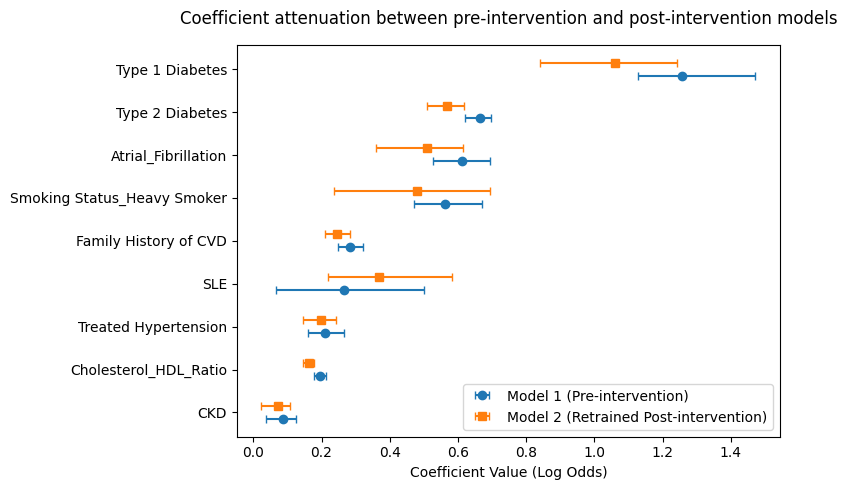

In [7]:
# Figure 1: Plot the coefficient attenuation between M1 and M2 for pre-specified features, 
# with the 2.5th-97.5th percentile intervals across 20 seeds 
fig, ax = plt.subplots(figsize=(8, 5))
y_positions = np.arange(len(top_features))

# Error bars takes distance form the point, not the boundadary itself, 
# need to subtract the percentiles to get the upper and lowe arm lengths 
m1_error = np.array([
    top_features["m1_mean"] - top_features["m1_p2.5"],
    top_features["m1_p97.5"] - top_features["m1_mean"],
])
m2_error = np.array([
    top_features["m2_mean"] - top_features["m2_p2.5"],
    top_features["m2_p97.5"] - top_features["m2_mean"],
])

# Plot M1 and M2 with the vertical offsets so the two series don't sit on top of each other 
ax.errorbar(top_features["m1_mean"], y_positions - 0.15, xerr=m1_error,
            fmt="o", color="#1f77b4", ecolor="#1f77b4", capsize=3, linewidth=1.5, label="Model 1 (Pre-intervention)")
ax.errorbar(top_features["m2_mean"], y_positions + 0.15, xerr=m2_error,
            fmt="s", color="#ff7f0e", ecolor="#ff7f0e", capsize=3, linewidth=1.5, label="Model 2 (Retrained Post-intervention)")

ax.set_yticks(y_positions)
ax.set_yticklabels(top_features["feature"])
ax.set_xlabel("Coefficient Value (Log Odds)")
ax.set_title(
    "Coefficient attenuation between pre-intervention and post-intervention models",
    fontsize=12,
    pad=15,
)
ax.legend(loc="best", frameon=True)

plt.tight_layout()

# Save figures 
from pathlib import Path 
Path("Results/Figures").mkdir(parents=True, exist_ok=True)

fig.savefig("Results/Figures/Attenuation.png", dpi=300, bbox_inches="tight")
fig.savefig("Results/Figures/Attenuation.svg", bbox_inches="tight")

plt.show()

### Calibration on Population C

In [8]:
# Fetch per-patient predictions on population C for the calibration plot
output = simulation.run_pipeline(42, n=100_000)
y_c = output["y_c"]
m1_pred = output["m1_predicted_risk_c"]
m2_pred = output["m2_predicted_risk_c"]

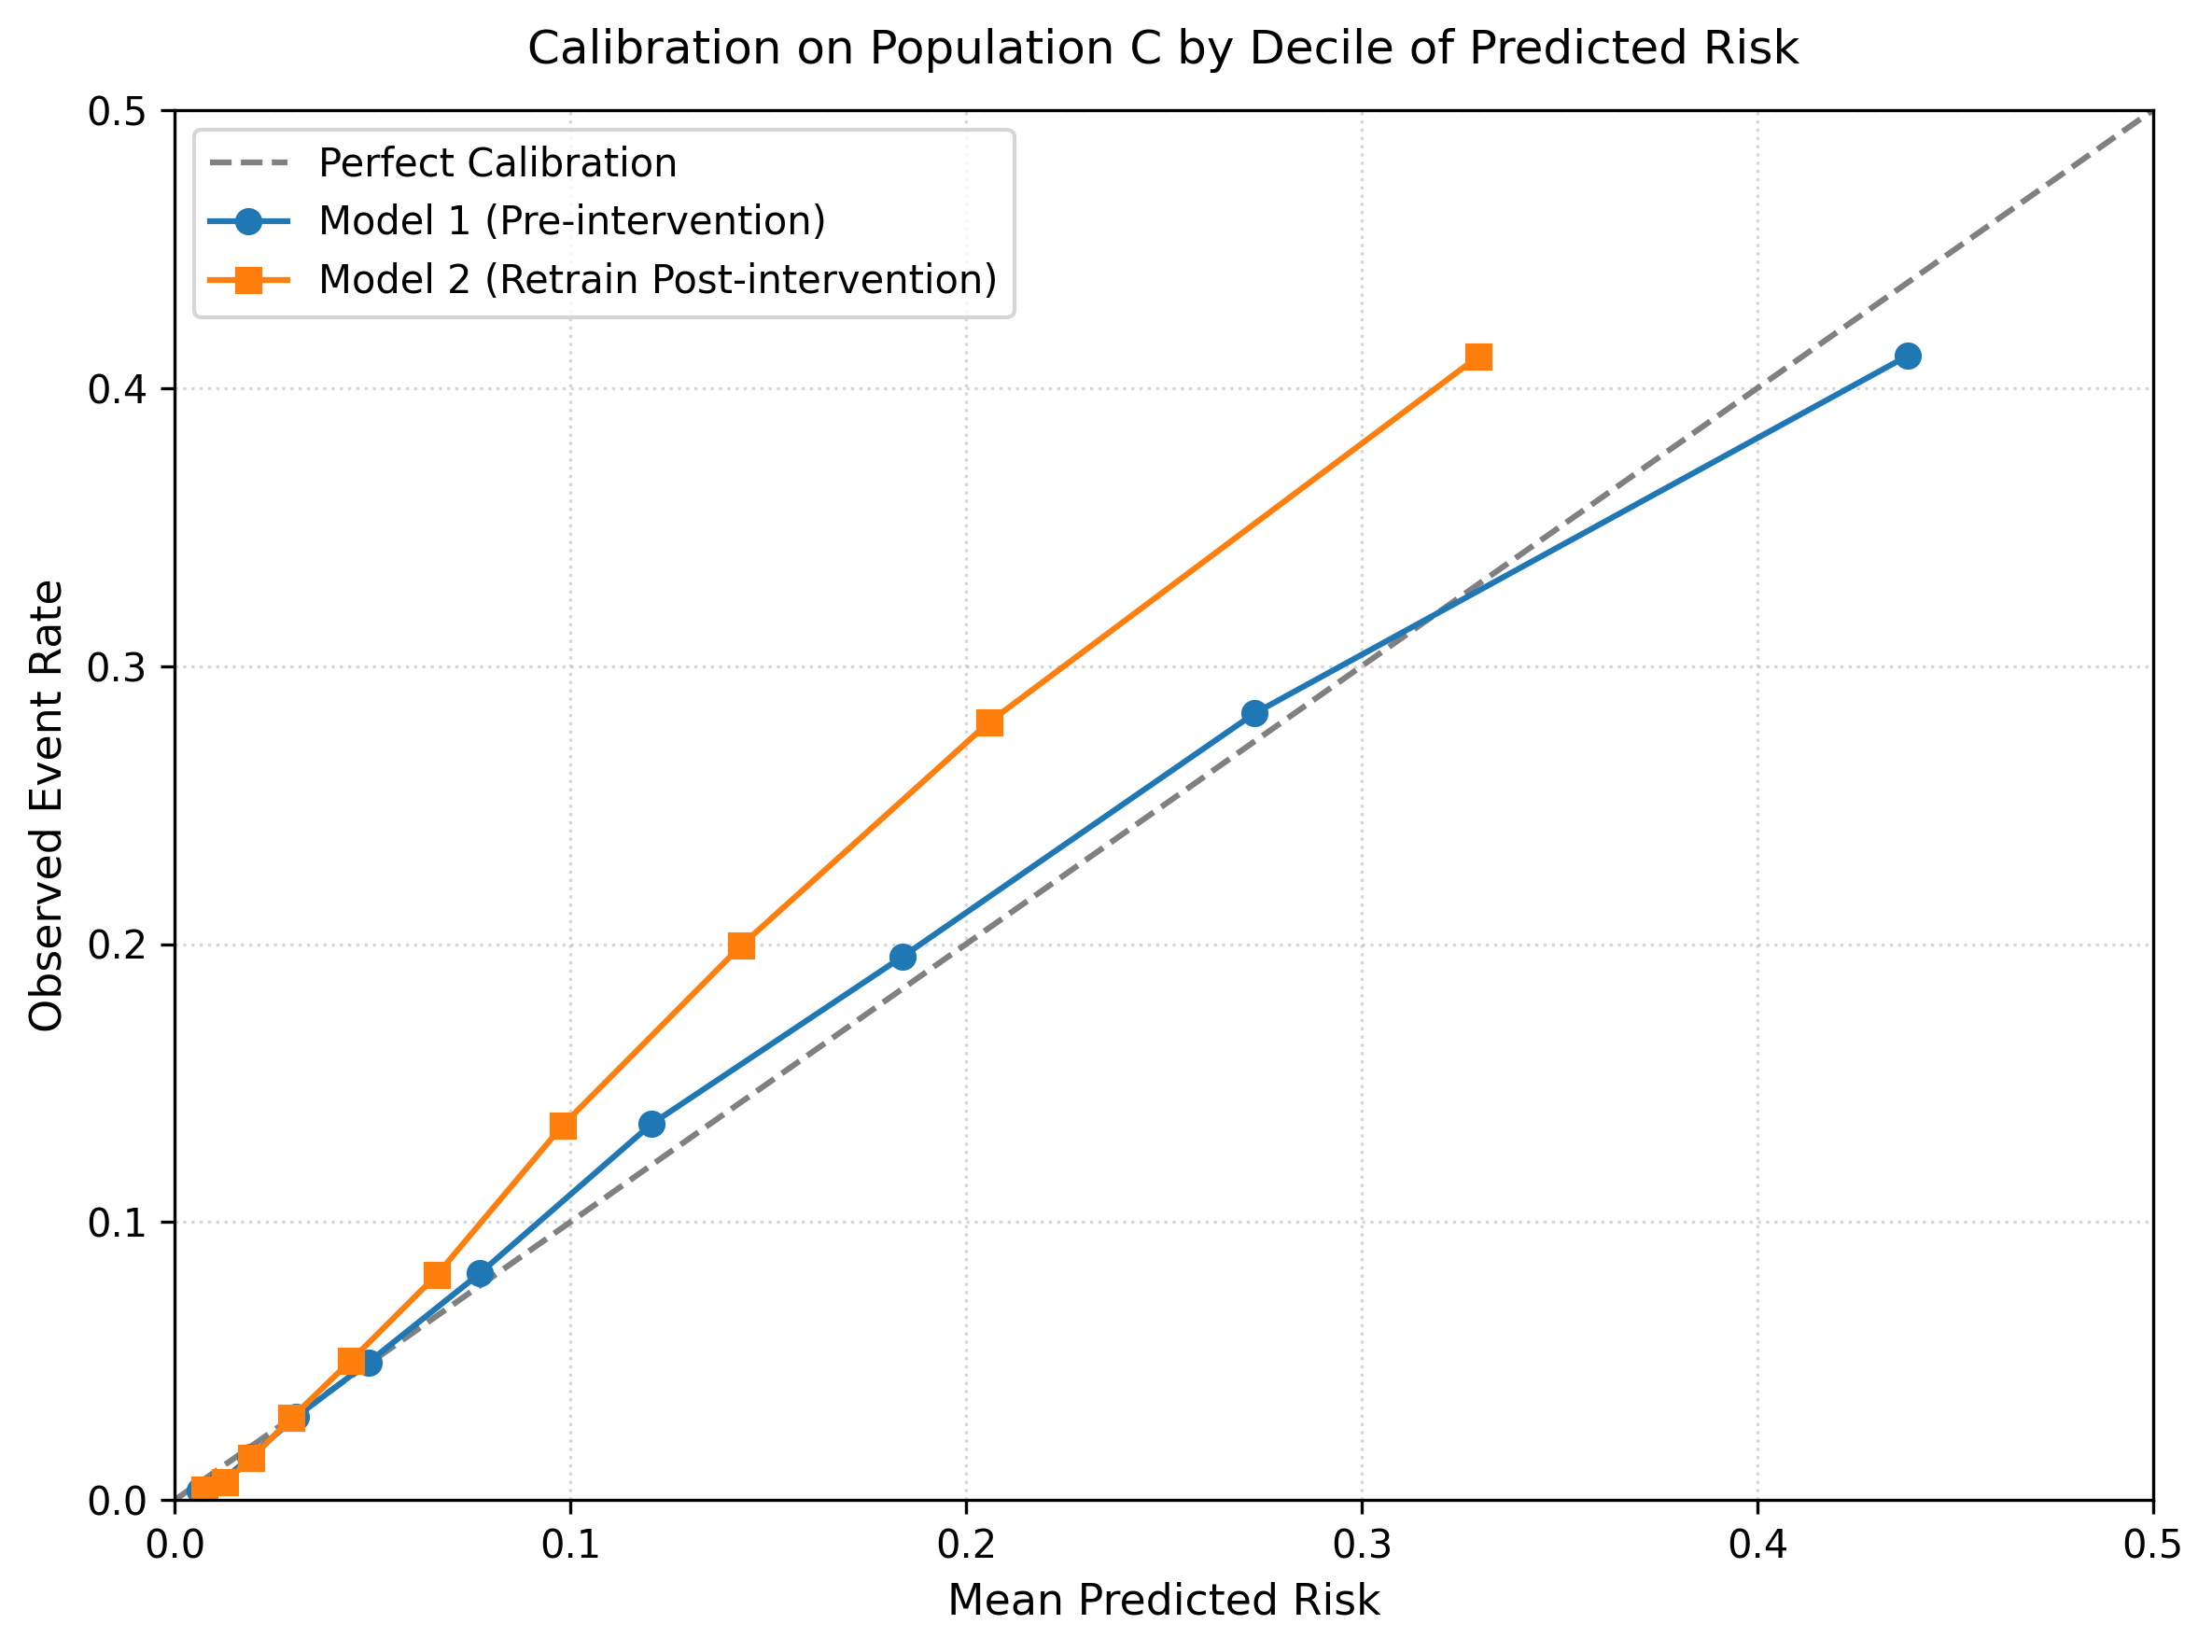

In [9]:
# Calculate decile calibration coordinates
m1_predicted, m1_observed = simulation.calibration_points(y_c, m1_pred)
m2_predicted, m2_observed = simulation.calibration_points(y_c, m2_pred)

# Figure 2: Plot the decile calibration on Population C. Points above the diagonal indicate under-prediction. 
# Single seed (42), since calibration requires per-patient predictions rather than summary statistics.
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# Reference Line 
ax.plot([0, 0.5], [0, 0.5], "--", color="grey", label="Perfect Calibration")

# Model calibration curves
ax.plot(
    m1_predicted,
    m1_observed,
    "o-",
    color="#1f77b4",
    linewidth=1.5,
    markersize=6,
    label="Model 1 (Pre-intervention)",
)

ax.plot(
    m2_predicted,
    m2_observed,
    "s-",
    color="#ff7f0e",
    linewidth=1.5,
    markersize=6,
    label="Model 2 (Retrain Post-intervention)",
)

ax.set_xlim([0, 0.5])
ax.set_ylim([0, 0.5])
ax.set_xlabel("Mean Predicted Risk", fontsize=11)
ax.set_ylabel("Observed Event Rate", fontsize=11)
ax.set_title("Calibration on Population C by Decile of Predicted Risk", fontsize=12, pad=12)
ax.grid(True, linestyle=":", alpha=0.5)
ax.legend(loc="upper left", frameon=True)

plt.tight_layout()

# Save images 
fig.savefig("Results/Figures/Calibration_M1_vs_M2.png", dpi=300, bbox_inches="tight")
fig.savefig("Results/Figures/Calibration_M1_vs_M2.svg", bbox_inches="tight")

plt.show()

# Experiment 2 - Sensitivity to treatment effect and uptake

Question: Is MICS a binary phenomenon or is it a continuous function of intervention intensity?

The experiment sweeped differnet relative risk reductions (0.15, 0.25, 0.40) against varying uptake levels (0.25, 0.50, 0.75, 1.00). The RRRs show how much statins lower a treated patient's risk; while the uptakes show the proportion of eligible patients who accepted treatment.

The proposal initially predicted that both relationships would be monotonic and increasing.

### Parameter sweep

In [10]:
from pathlib import Path

sweep_dir = Path("Results/Experiment_2")
sweep_dir.mkdir(parents=True, exist_ok=True)

rrr_values = [0.15, 0.25, 0.40]
uptake_values = [0.25, 0.50, 0.75, 1.0]

for rrr in rrr_values:
    for uptake in uptake_values:
        for seed in range(20):
            output_path = sweep_dir / f"rrr{int(rrr*100)}_uptake{int(uptake*100)}_seed{seed}.parquet"

            # Skip combinations already saved, so a kernal restart doesn't re-compute what is already on the disk
            if output_path.exists():
                continue

            result = simulation.run_simulation(seed, n=100_000, rrr=rrr, uptake=uptake)
            pl.DataFrame([result]).write_parquet(output_path)

    print(f"rrr {rrr} complete")

rrr 0.15 complete
rrr 0.25 complete
rrr 0.4 complete


 ### Summary across RRR and uptake

In [11]:
# Table 2: Produce the under-prediction, proportion treated and patients flagged by M2,
# across different combinations of relative risk reduction and treatment uptake
sweep = pl.read_parquet("Results/Experiment_2/*.parquet")
print(sweep.shape)

sweep_summary = (
    sweep
    .group_by(["rrr", "uptake"])
    .agg([
        pl.col("underprediction_vs_truth_pp").mean().alias("underprediction_mean"),
        pl.col("underprediction_vs_truth_pp").std().alias("underprediction_sd"),
        pl.col("proportion_treated").mean(),
        pl.col("m2_n_flagged").mean(),
    ])
    .sort(["rrr", "uptake"])
)
sweep_summary

(240, 97)


rrr,uptake,underprediction_mean,underprediction_sd,proportion_treated,m2_n_flagged
f64,f64,f64,f64,f64,f64
0.15,0.25,0.378948,0.115882,0.09766,38586.25
0.15,0.5,0.758902,0.109073,0.1956475,37965.35
0.15,0.75,1.141156,0.112261,0.2936845,37291.55
0.15,1.0,1.522449,0.118717,0.391658,36560.65
0.25,0.25,0.620447,0.12122,0.09766,38215.55
…,…,…,…,…,…
0.25,1.0,2.527236,0.108361,0.391658,34360.15
0.4,0.25,0.999045,0.118283,0.09766,37571.15
0.4,0.5,2.016457,0.122707,0.1956475,35542.75


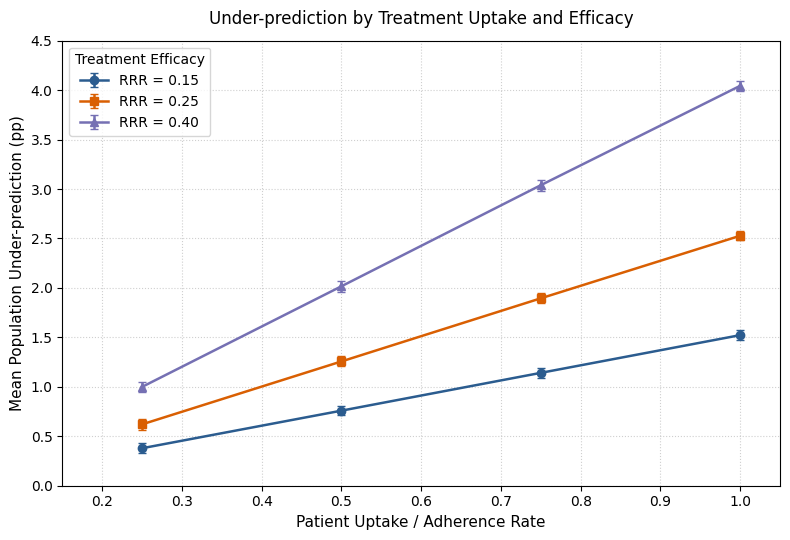

In [12]:
# Compute the effective treatment intensity 
plot_data = sweep_summary.with_columns(
    effective_intensity=(pl.col("rrr") * pl.col("uptake"))
)

# 95% CI across 20 seeds
n_seeds = 20

# Figure 3: Plot under-prediction by treatment uptake, one line per RRR 
# The error bars are 1.96 x standard error across the seeds 
fig, ax = plt.subplots(figsize=(8, 5.5))

rrr_values = plot_data["rrr"].unique().sort()
colors = ["#2b5c8f", "#d95f02", "#7570b3"]  
markers = ["o", "s", "^"]

for rrr_val, color, marker in zip(rrr_values, colors, markers):
    sub = plot_data.filter(pl.col("rrr") == rrr_val).sort("uptake")
    ax.errorbar(
        x=sub["uptake"],
        y=sub["underprediction_mean"],
        yerr=1.96 * sub["underprediction_sd"] / np.sqrt(n_seeds),  
        fmt=f"{marker}-",
        color=color,
        linewidth=1.8,
        markersize=6,
        capsize=3,
        label=f"RRR = {rrr_val:.2f}",
    )

ax.set_xlim([0.15, 1.05])
ax.set_ylim([0, 4.5])
ax.set_xlabel("Patient Uptake / Adherence Rate", fontsize=11)
ax.set_ylabel("Mean Population Under-prediction (pp)", fontsize=11)
ax.set_title(
    "Under-prediction by Treatment Uptake and Efficacy",
    fontsize=12,
    pad=12,
)
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(title="Treatment Efficacy", loc="upper left", frameon=True)

plt.tight_layout()

plt.savefig("Results/Figures/Underprediction_vs_Uptake.png", dpi=300, bbox_inches="tight")
fig.savefig("Results/Figures/Underprediction_vs_Uptake.svg", bbox_inches="tight")

plt.show()

### Effective treatment intensity

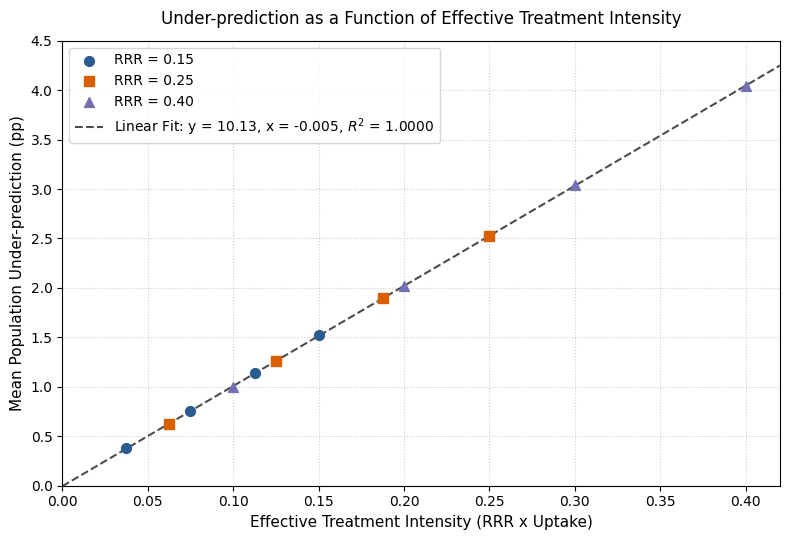

Slope 10.1283
Intercept -0.0049
R^2 0.999973


In [13]:
# Figure 4: Plot under-prediction against effective treatment intensity (RRR x Uptake), 
# with linear fit and R^2. All the combinations should collapse into a single line, 
# indicating that the two parameters act only through their product.
fig, ax = plt.subplots(figsize=(8, 5.5))

# Extract X and Y vectors for a linear regression fit
x_effect = plot_data["effective_intensity"].to_numpy()
y_underprediction = plot_data["underprediction_mean"].to_numpy()

# Fit linear regression through origin 
# linregress returns the correlation coefficient as well as the fit, so R^2
# quantifies how closely the twelve points collapse onto a single line
fit = stats.linregress(x_effect, y_underprediction)
r_squared = fit.rvalue ** 2

# Plot distinct points grouped by RRR for visual traceability
for rrr_val, color, marker in zip(rrr_values, colors, markers):
    sub = plot_data.filter(pl.col("rrr") == rrr_val)
    ax.scatter(
        sub["effective_intensity"],
        sub["underprediction_mean"],
        color=color,
        marker=marker,
        s=50,
        zorder=3,
        label=f"RRR = {rrr_val:.2f}",
    )

# Fitted trendline across the full range showing the collapse
x_line = np.linspace(0, 0.42, 100)
y_line = fit.slope * x_line + fit.intercept
ax.plot(
    x_line,
    y_line,
    "k--",
    alpha=0.7,
    linewidth=1.5,
    label=f"Linear Fit: y = {fit.slope:.2f}, x = {fit.intercept:+.3f}, $R^2$ = {r_squared:.4f}",
)

ax.set_xlim([0.0, 0.42])
ax.set_ylim([0.0, 4.5])
ax.set_xlabel("Effective Treatment Intensity (RRR x Uptake)",fontsize=11)
ax.set_ylabel("Mean Population Under-prediction (pp)", fontsize=11)
ax.set_title(
    "Under-prediction as a Function of Effective Treatment Intensity",
    fontsize=12,
    pad=12,
)
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(loc="upper left", frameon=True)

plt.tight_layout()

plt.savefig("Results/Figures/Effective_Intensity_Collapse.png", dpi=300, bbox_inches="tight")
fig.savefig("Results/Figures/Effective_Intensity_Collapse.svg", bbox_inches="tight")

plt.show()

print(f"Slope {fit.slope:.4f}")
print(f"Intercept {fit.intercept:.4f}")
print(f"R^2 {r_squared:.6f}")

In [14]:
# Table 3: Enusre the fitted values match against measured under-prediction, with residuals,
# this serves as a check on the linear relationship seen in Figure 4
plot_check = plot_data.with_columns(
    predicted_underprediction=(fit.slope * pl.col("effective_intensity") + fit.intercept)
).with_columns(
    residual=(pl.col("underprediction_mean") - pl.col("predicted_underprediction"))
).select([
    "rrr", "uptake", "effective_intensity",
    "underprediction_mean", "predicted_underprediction", "residual"
])
plot_check

rrr,uptake,effective_intensity,underprediction_mean,predicted_underprediction,residual
f64,f64,f64,f64,f64,f64
0.15,0.25,0.0375,0.378948,0.374928,0.004021
0.15,0.5,0.075,0.758902,0.754737,0.004165
0.15,0.75,0.1125,1.141156,1.134547,0.006608
0.15,1.0,0.15,1.522449,1.514357,0.008092
0.25,0.25,0.0625,0.620447,0.628134,-0.007687
…,…,…,…,…,…
0.25,1.0,0.25,2.527236,2.527183,0.000053
0.4,0.25,0.1,0.999045,1.007944,-0.008899
0.4,0.5,0.2,2.016457,2.02077,-0.004313


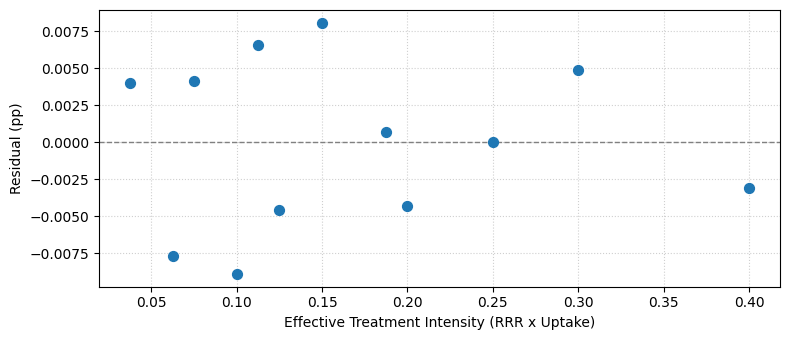

In [15]:
# Figure 5: Plot the residuals from the linear fit in Figure 4. Residuals scattered aroud zero 
# with no fixed pattern indicate that the linear plot is the right model; 
# as there should be no systematic depature from linearity 
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.scatter(plot_check["effective_intensity"], plot_check["residual"], s=50, zorder=3)
ax.axhline(0, color="grey", linestyle="--", linewidth=1)
ax.set_xlabel("Effective Treatment Intensity (RRR x Uptake)")
ax.set_ylabel("Residual (pp)")
ax.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# Experiment 3 — Statin as a covariate

Question: Does conditioning M2 on treatment exposure restore its predictive accuracy?

M2 was retrained with patient statin status included as a feature. Only a partial
restoration was expected, since M2's other coefficients would remain attenuated and
conditioning on treatment alone would not undo that.

**Deployment assumption:** Nobody in population C had been allocated statins, so the
covariate needed a value at prediction time. This experiment set it to zero,
which asked M2 for each patient's untreated risk. An M1-implied alternative would
require M1 to still exist at deployment - this comparison is a possible extension as clinicians would know who had already been assigned statins when using the model. 

### Baseline vs covariate runs

In [16]:
exp3_dir = Path("Results/Experiment_3")
exp3_dir.mkdir(parents=True, exist_ok=True)

for statin_covariate in [False, True]:
    for seed in range(20):
        label = "Covariate" if statin_covariate else "Baseline"
        output_path = exp3_dir / f"{label}_seed{seed}.parquet"

        if output_path.exists():
            continue

        result = simulation.run_simulation(
            seed, n=100_000, statin_covariate=statin_covariate
        )
        pl.DataFrame([result]).write_parquet(output_path)

    runs = pl.read_parquet(f"Results/Experiment_3/{label}_*.parquet")
    print(f"{label} Complete: {runs.shape}")

Baseline Complete: (20, 97)
Covariate Complete: (20, 98)


In [17]:
baseline_runs = pl.read_parquet("Results/Experiment_3/Baseline_*.parquet")
covariate_runs = pl.read_parquet("Results/Experiment_3/Covariate_*.parquet")

### Under-prediction and treatment coefficients

In [18]:
# Table 4: Show the under-prediction with and without statin status as a covariate,
# paired by seed across the 20 replicates
baseline_underprediction = np.asarray(baseline_runs["underprediction_vs_truth_pp"])
covariate_underprediction = np.asarray(covariate_runs["underprediction_vs_truth_pp"])

# The difference is paired by seed, so the same populations are compared and seed-to-seed
# variation gets cancelled out
difference = covariate_underprediction - baseline_underprediction

print(f"Baseline: {baseline_underprediction.mean():.4f}")
print(f"Covariate: {covariate_underprediction.mean():.4f}")
print(f"Reduction: {-difference.mean():.4f} pp "
      f"(Percentage - {-difference.mean() / baseline_underprediction.mean() * 100:.1f}%)")
print(f"SE of Difference: {difference.std(ddof=1) / np.sqrt(len(difference)):.4f}")

Baseline: 2.5272
Covariate: 1.6536
Reduction: 0.8736 pp (Percentage - 34.6%)
SE of Difference: 0.0816


In [19]:
# The On_Statins coefficeint should approach log(1-rrr) = -0.2877, if M2 has learned the effect of statins 

on_statins = np.asarray(covariate_runs["m2_coefficient_On_Statins"])
print(f"On_Statins: {on_statins.mean():.4f} "
    f"± {on_statins.std(ddof=1) / np.sqrt(len(on_statins)):.4f}")
print(f"True Value: {np.log(0.75):.4f}")


On_Statins: -0.1458 ± 0.0133
True Value: -0.2877


In [20]:
# Assess whether the improvement is a level shift or a structural correction.
# If it is a level shift, M2's intercept moves toward M1's while the 
# risk-factor coefficients stay attenuated.

m1_int = np.asarray(baseline_runs["m1_intercept"])
m2_base_int = np.asarray(baseline_runs["m2_intercept"])
m2_cov_int = np.asarray(covariate_runs["m2_intercept"])

print(f"M1: {m1_int.mean():.4f}")
print(f"M2 Baseline: {m2_base_int.mean():.4f}")
print(f"M2 Covariate: {m2_cov_int.mean():.4f}")

# The proportion of the intercept gap that the statin covariate closes 
# When compared against the percentage reduction 34.6% a match indicates a level shift,
# while a larger gap suggests a structural change 
print(f"Gap Closed: {(m2_cov_int - m2_base_int).mean() / (m1_int - m2_base_int).mean() * 100:.1f}%")

M1: -8.9721
M2 Baseline: -8.2397
M2 Covariate: -8.4504
Gap Closed: 28.8%


### Uptake sweep

In [21]:
exp3_uptake_dir = Path("Results/Experiment_3_Uptake")
exp3_uptake_dir.mkdir(parents=True, exist_ok=True)

for uptake in [0.25, 0.50, 0.75, 1.0]:
    for seed in range(20):
        output_path = exp3_uptake_dir / f"Uptake{int(uptake*100)}_seed{seed}.parquet"

        if output_path.exists():
            continue

        result = simulation.run_simulation(
            seed, n=100_000, uptake=uptake, statin_covariate=True
        )
        pl.DataFrame([result]).write_parquet(output_path)

    print(f"Uptake {uptake} Complete")

Uptake 0.25 Complete
Uptake 0.5 Complete
Uptake 0.75 Complete
Uptake 1.0 Complete


In [22]:
# Table 5: Show the under-prediction and the fitted statin coefficient by the uptake level,
# with the statin covariate included. The coefficient approaches its true value log(1 - RRR) = -0.2877 
# at lower uptake, and then collapses at full uptake where treatment status 
# is nearly collinear with predicted risk.
uptake_runs = pl.read_parquet("Results/Experiment_3_Uptake/*.parquet")

uptake_summary = (
    uptake_runs
    .group_by("uptake")
    .agg([
        pl.col("m2_coefficient_On_Statins").mean().alias("on_statins_mean"),
        pl.col("m2_coefficient_On_Statins").std().alias("on_statins_sd"),
        pl.col("underprediction_vs_truth_pp").mean().alias("underprediction_mean"),
    ])
    .sort("uptake")
)
uptake_summary

uptake,on_statins_mean,on_statins_sd,underprediction_mean
f64,f64,f64,f64
0.25,-0.375419,0.025043,0.035022
0.5,-0.369376,0.030276,0.105261
0.75,-0.336008,0.036816,0.329766
1.0,-0.145767,0.059674,1.653592


In [23]:
# Table 6: Show that under-prediction is reduced by including statin as a covariate, comparing the same uptake
# levels with and without it at the RRR 0.25
no_covariate = (
    pl.read_parquet("Results/Experiment_2/*.parquet")
    .filter(pl.col("rrr") == 0.25)
    .group_by("uptake")
    .agg(pl.col("underprediction_vs_truth_pp").mean().alias("underprediction_no_covariate"))
)

with_covariate = (
    pl.read_parquet("Results/Experiment_3_Uptake/*.parquet")
    .group_by("uptake")
    .agg([
        pl.col("underprediction_vs_truth_pp").mean().alias("underprediction_with_covariate"),
        pl.col("m2_coefficient_On_Statins").mean().alias("on_statins_coefficient"),
    ])
)

exp3_comparison = (
    no_covariate
    .join(with_covariate, on="uptake")
    .with_columns(
        underprediction_reduction_pct=(
            (pl.col("underprediction_no_covariate") - pl.col("underprediction_with_covariate"))
            / pl.col("underprediction_no_covariate") * 100
        )
    )
    .sort("uptake")
)
exp3_comparison

uptake,underprediction_no_covariate,underprediction_with_covariate,on_statins_coefficient,underprediction_reduction_pct
f64,f64,f64,f64,f64
0.25,0.620447,0.035022,-0.375419,94.35531
0.5,1.256617,0.105261,-0.369376,91.623428
0.75,1.894837,0.329766,-0.336008,82.596608
1.0,2.527236,1.653592,-0.145767,34.569149


### Feature-level coefficient recovery

In [24]:
# Tabel 7: Assess whether the statin covarite restores the attenuated coeffcients, or only shifts their levels 
# For each feature compare how far M2 sits from M1 with and without the covariate,
# and what proportion of the attenuation the statin covariate recovers

feature_list = [
    c.replace("m1_coefficient_", "")
    for c in baseline_runs.columns
    if c.startswith("m1_coefficient_")
]

rows = []
for feature in feature_list:
    m1 = np.asarray(baseline_runs[f"m1_coefficient_{feature}"])
    m2_baseline = np.asarray(baseline_runs[f"m2_coefficient_{feature}"])
    m2_covariate = np.asarray(covariate_runs[f"m2_coefficient_{feature}"])

    # The attenuation in each version, measured against M1
    gap_baseline = m2_baseline - m1
    gap_covariate = m2_covariate - m1

    # Recovary as the covariate's effect on identical populations; paired by seed 
    recovery = gap_covariate - gap_baseline
    recovery_se = recovery.std(ddof=1) / np.sqrt(len(recovery))

    rows.append({
        "feature": feature,
        "m1_mean": np.mean(m1),
        "m2_baseline_mean": np.mean(m2_baseline),
        "m2_covariate_mean": np.mean(m2_covariate),
        "gap_baseline_mean": np.mean(gap_baseline),
        "gap_covariate_mean": np.mean(gap_covariate),
        "recovery_mean": np.mean(recovery),
        "recovery_se": recovery_se,
    })

exp3_features = pl.DataFrame(rows)

# Find the proportion of the baseline attenuation that the covariate actually recovers.
# This is computed from the means rather than per seed, since gap_baseline can be
# near zero for features that barely attenuate.
exp3_features = exp3_features.with_columns(
    recovery_proportion=(pl.col("recovery_mean") / -pl.col("gap_baseline_mean"))
)

# Filter to the features that actually attenuate, so that recovery is meaningful 
exp3_features.filter(
    pl.col("feature").is_in(figure_features)
).sort("gap_baseline_mean")

feature,m1_mean,m2_baseline_mean,m2_covariate_mean,gap_baseline_mean,gap_covariate_mean,recovery_mean,recovery_se,recovery_proportion
str,f64,f64,f64,f64,f64,f64,f64,f64
"""Type 1 Diabetes""",1.257299,1.059692,1.099649,-0.197607,-0.15765,0.039957,0.006599,0.202206
"""Atrial_Fibrillation""",0.613088,0.510637,0.509774,-0.102451,-0.103313,-0.000862,0.002874,-0.008418
"""Type 2 Diabetes""",0.664085,0.568731,0.589099,-0.095354,-0.074987,0.020368,0.002362,0.213602
"""Smoking Status_Heavy Smoker""",0.56266,0.481205,0.492959,-0.081455,-0.0697,0.011755,0.004197,0.14431
"""Family History of CVD""",0.28264,0.246785,0.256508,-0.035855,-0.026132,0.009724,0.001112,0.271191
"""Cholesterol_HDL_Ratio""",0.195318,0.162178,0.168407,-0.03314,-0.026911,0.006229,0.000611,0.18796
"""CKD""",0.086972,0.073032,0.07109,-0.01394,-0.015882,-0.001942,0.000534,-0.139324
"""Treated Hypertension""",0.209404,0.198041,0.205919,-0.011363,-0.003486,0.007878,0.000787,0.693236
"""SLE""",0.265841,0.3679,0.367389,0.102059,0.101548,-0.000511,0.014706,0.005007


# Experiment 4 — Differential uptake by ethnicity (sub group analysis)

Question: Does MICS degrade model performance unequally across different subgroups?

Uptake will be allowed to vary by ethnic group rather than be constant. The
proposal predicts that ethnic groups with higher uptake will show greater coefficient
attenuation, and that an ethnicity × treatment interaction term may partially mitigate this.
Differential uptake is modelled here as a stylised parameter; in practice it reflects structural factors including access to care, prescribing patterns, deprivation and trust in health services.

Encoding ethnicity in clinical algorithms risks naturalising inequalities that may be structural and external rather than biological - a tension this project acknowledges but does not resolve.

*Not yet implemented. Groundwork done: `uptake` is already a parameter of  `apply_statin_intervention`, which is currently a scalar.*

In [25]:
# CODE CHANGES NEEDED:
#  1. Allow uptake to be a dictionary keyed by ethnicity, not just a float number
#  2. Per-group results: the attenuation values and metrics for each ethnic group
#     which will change the shape of the results dict
#  3. A third M2 specification with separate ethnicity × treatment interaction terms
#  4. hread any new parameters through run_pipeline AND run_simulation,
#     at both the signature and the call site 

#
# TWO VARIANTS TO RUN:
#   a) Differential uptake as proposed 
#   b) Equal uptake as a baseline, for comparison

### Upatake Conditions 

In [26]:
# Use stylised uptake rates, chosen to span a plausible range accross ethnicities.
# These are illustractive rather than emprical estimates; the analysis test whether differentical uptake
# produces heterogeneous MICS effects, not if the magnitude of those effects are in any real population 

# Condition on different uptake measures 
# B: Differential uptake across enthic groups 
differential_uptake = {
    "White":  0.75, 
    "Indian": 0.70,
    "Pakistani": 0.60,
    "Bangladeshi": 0.55,
    "Chinese": 0.68,
    "Other Asian": 0.65,
    "Black Caribbean": 0.58,
    "Black African": 0.62, 
    "Other Ethnic Group": 0.65
}

# A: Equal uptake, set to the population-weighted mean of Condition B, so both conditions treat 
# the same total number of patients and only the distribution of treatment differs
equal_uptake = {group: 0.7294 for group in differential_uptake}

In [ ]:
# Single-seed check to esnure that per-group results are produced correctly.
# This is not a final result as group sizes below ~5,000 are too small to interpret from one seed.

result = simulation.run_simulation(0, n=100_000, uptake = differential_uptake)

rows = []
for group in differential_uptake:
    rows.append({
        "group": group,
        "n": result[f"n_{group}"],
        "uptake_value": differential_uptake[group],
        "treated": result[f"treated_{group}"],
        "m1_pred": result[f"m1_mean_pred_{group}"],
        "m2_pred": result[f"m2_mean_pred_{group}"],
        "gap_pp": (result[f"m1_mean_pred_{group}"] - result[f"m2_mean_pred_{group}"]) * 100,
    })

pl.DataFrame(rows).sort("uptake_value", descending=True)


# Multi-seed run
exp4_dir = Path("Results/Experiment_4")
exp4_dir.mkdir(parents=True, exist_ok=True)

conditions = {"Equal": equal_uptake, "Differential": differential_uptake}

for label, uptake_rates in conditions.items():
    for seed in range(20):
        output_path = exp4_dir / f"{label}_seed{seed}.parquet"

        if output_path.exists():
            continue

        result = simulation.run_simulation(seed, n=100_000, uptake = uptake_rates)
        pl.DataFrame([result]).write_parquet(output_path)

    print(f"{label} Complete")

equal_runs = pl.read_parquet("Results/Experiment_4/Equal_*.parquet")
differential_runs = pl.read_parquet("Results/Experiment_4/Differential_*.parquet")

Equal Complete
Differential Complete


### Under-prediction by ethnic group 

In [ ]:
# Table 8: Under-prediction by ethnic group under equal versus differential uptake
# Compare each group's M1 and M2 gap under differential uptake against the same group's gap
# under equal uptake. Both conditions treat the same number of pateints so the difference isolates 
# the effect of unequal treatment distribution 

rows = []

for group in differential_uptake:
    equal_gap = (
        np.asarray(equal_runs[f"m1_mean_pred_{group}"])
        - np.asarray(equal_runs[f"m2_mean_pred_{group}"])
    ) * 100

    differential_gap = (
        np.asarray(differential_runs[f"m1_mean_pred_{group}"])
        - np.asarray(differential_runs[f"m2_mean_pred_{group}"])
    ) * 100

    uptake_difference = differential_gap - equal_gap

    mean_difference = np.mean(uptake_difference)
    se_difference = stats.sem(uptake_difference)

    rows.append({
        "ethnic_group": group,
        "n": int(np.asarray(equal_runs[f"n_{group}"]).mean()),
        "uptake_rate": differential_uptake[group],
        "equal_gap_pp": np.mean(equal_gap),
        "differential_gap_pp": np.mean(differential_gap),
        "change_pp": mean_difference,
        "se": se_difference,
        "ci_low": mean_difference - 1.96 * se_difference,
        "ci_high": mean_difference + 1.96 * se_difference,
    })

exp4_attenuation = pl.DataFrame(rows).sort("uptake_rate", descending=True)
exp4_attenuation

ethnic_group,n,uptake_rate,equal_gap_pp,differential_gap_pp,change_pp,se,ci_low,ci_high
str,i64,f64,f64,f64,f64,f64,f64,f64
"""White""",81665,0.75,1.820839,1.87508,0.054241,0.002114,0.050097,0.058385
"""Indian""",3111,0.7,2.59971,2.496986,-0.102724,0.01071,-0.123715,-0.081732
"""Chinese""",698,0.68,0.982993,0.902338,-0.080655,0.047449,-0.173655,0.012345
"""Other Asian""",1599,0.65,2.146449,1.984617,-0.161832,0.019884,-0.200804,-0.12286
"""Other Ethnic Group""",5123,0.65,1.546691,1.396895,-0.149796,0.016661,-0.182451,-0.117141
"""Black African""",2995,0.62,1.087959,0.942901,-0.145058,0.01337,-0.171263,-0.118853
"""Pakistani""",2717,0.6,3.029248,2.474012,-0.555237,0.048792,-0.650869,-0.459604
"""Black Caribbean""",998,0.58,1.437397,1.189063,-0.248334,0.046782,-0.340027,-0.156641
"""Bangladeshi""",1091,0.55,2.287855,1.604007,-0.683848,0.051844,-0.785462,-0.582234


### Attenuation of ethnicity coefficients

In [ ]:
# Table 9: Attenuation of ethnicity coefficients under equal and differential
# uptake, paired by seed across 20 replicates. White is the reference category 
# and has no coeffienct of its own

rows = []

for group in differential_uptake:
    if group == "White":
        continue

    column = f"Ethnicity_{group}"

    equal_attenuation = (
        np.asarray(equal_runs[f"m2_coefficient_{column}"])
        - np.asarray(equal_runs[f"m1_coefficient_{column}"])
    )
    differential_attenuation = (
        np.asarray(differential_runs[f"m2_coefficient_{column}"])
        - np.asarray(differential_runs[f"m1_coefficient_{column}"])
    )

    attenuation_difference = differential_attenuation - equal_attenuation

    rows.append({
        "ethnic_group": group,
        "n": int(np.asarray(equal_runs[f"n_{group}"]).mean()),
        "uptake_rate": differential_uptake[group],
        "equal_attenuation": np.mean(equal_attenuation),
        "differential_attenuation": np.mean(differential_attenuation),
        "change": np.mean(attenuation_difference),
        "se": stats.sem(attenuation_difference),
    })

exp4_coefficients = pl.DataFrame(rows).sort("uptake_rate", descending=True)
exp4_coefficients

ethnic_group,n,uptake_rate,equal_attenuation,differential_attenuation,change,se
str,i64,f64,f64,f64,f64,f64
"""Indian""",3111,0.7,-0.055601,-0.037958,0.017643,0.001073
"""Chinese""",698,0.68,0.073079,0.092685,0.019606,0.007406
"""Other Asian""",1599,0.65,-0.034742,-0.008091,0.026651,0.002291
"""Other Ethnic Group""",5123,0.65,0.012161,0.04048,0.028319,0.002469
"""Black African""",2995,0.62,0.058558,0.088847,0.03029,0.001982
"""Pakistani""",2717,0.6,-0.071804,-0.013953,0.057851,0.004504
"""Black Caribbean""",998,0.58,0.022239,0.066429,0.04419,0.007084
"""Bangladeshi""",1091,0.55,-0.013666,0.058995,0.072661,0.005228
